# 🚀 Stage 2: Augmenting with Local N-Gram Repetition & Token ID Distribution Profiling

## 🎯 Executive Overview & Stage Objectives
- **Target**: Increase classification accuracy above **Stage 1 (89.69%)** and the **Baseline (89.23%)**.
- **Stage 2 Features Added**:
  1. **Distinct Bigram Ratio** ($	ext{Distinct\_Bi}$)
  2. **Distinct Trigram Ratio** ($	ext{Distinct\_Tri}$)
  3. **Mean Token ID** ($\mu_{	ext{token\_id}}$)
  4. **Standard Deviation of Token IDs** ($\sigma_{	ext{token\_id}}$)
  5. **Q1 Functional Stopword Ratio** (tokens with $	ext{ID} \le 3000$)
  6. **Q4 Rare Tail Token Ratio** (tokens with $	ext{ID} \ge 10000$)

### 📈 Accuracy Progress Tracker:
| Evaluation Stage | Cumulative Features Included | 5-Fold Mean Accuracy | Std Dev | $\Delta$ vs. Baseline | $\Delta$ vs. Prev Stage |
| :--- | :--- | :---: | :---: | :---: | :---: |
| **Baseline** | TF-IDF (1-5) + Document Length | **89.23%** | $\pm 0.75\%$ | — | — |
| **Stage 1** | + Lexical Diversity & Shannon Entropy | **89.69%** | $\pm 0.46\%$ | $+0.47\%$ | $+0.47\%$ |
| **Stage 2** | **+ N-Gram Repetition & Token ID Profiling** | **90.31%** | $\pm 0.44\%$ | **+1.08%** | **+0.62%** |

---

### 🔬 What Features Are Being Added and Why?

1. **Distinct Bigram & Trigram Ratios**:
   $$	ext{Distinct\_Bi} = rac{|	ext{unique bigrams}|}{L_d - 1}, \quad 	ext{Distinct\_Tri} = rac{|	ext{unique trigrams}|}{L_d - 2}$$
   - **Why it is added**: Autoregressive language models often exhibit cyclic local phrasing patterns and repetitive transition motifs across an essay. Human writers vary their transition phrasing with higher semantic variation.
   - *Empirical Difference*: Machine Distinct Bigrams = **0.91** vs. Human = **0.94**.

2. **Token ID Profiling ($\mu, \sigma, Q_1, Q_4$)**:
   - In subword tokenizers (BPE/WordPiece), token IDs are ordered by unigram corpus frequency. Lower IDs ($< 3000$) correspond to common functional words and grammatical syntax; higher IDs ($> 10000$) represent domain-specific, rare, or idiosyncratic vocabulary.
   - **Why it is added**: Nucleus sampling in LLMs truncates unlikely tail tokens, leading to an artificially lower proportion of rare vocabulary. Human authors naturally draw from the long tail of the vocabulary distribution.
   - *Empirical Difference*: Human Mean Token ID = **9,033.3** vs. Machine = **8,897.5** ($\Delta = -135.8$).


In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import scipy.sparse as sp
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

try:
    from IPython.display import display
except ImportError:
    display = print

# Styling configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

print("Dependencies loaded successfully!")


Dependencies loaded successfully!


In [2]:
# Load dataset
data_path = "../../../train.json"
if not os.path.exists(data_path):
    data_path = "/home/justin/PhD/ML4CPS/Kaggle Project/Analysis_II/train.json"

print(f"Loading data from: {os.path.abspath(data_path)}")
t0 = time.time()
with open(data_path, "r", encoding="utf-8") as f:
    raw_data = [json.loads(line) for line in f]

docs = [" ".join(map(str, d["text"])) for d in raw_data]
labels = np.array([1 if d["label"] == "B" else 0 for d in raw_data])
doc_tokens = [d["text"] for d in raw_data]

n_total = len(docs)
n_machine = int(np.sum(labels == 1))
n_human = int(np.sum(labels == 0))
majority_baseline = n_machine / n_total * 100
lens = np.array([len(t) for t in doc_tokens], dtype=np.float64)[:, None]

print(f"Loaded {n_total:,} documents in {time.time()-t0:.2f}s | Majority Baseline: {majority_baseline:.2f}%")


Loading data from: /home/justin/PhD/ML4CPS/Kaggle Project/Analysis_II/train.json


Loaded 10,536 documents in 0.82s | Majority Baseline: 64.89%


## 2. Feature Extraction: Stage 1 + Stage 2 Augmentations


In [3]:
# Stage 1: Lexical Diversity & Entropy
def extract_stage1(tokens):
    n = len(tokens)
    counts = Counter(tokens)
    probs = np.array(list(counts.values())) / n
    ent = -np.sum(probs * np.log2(probs))
    root_ttr = len(counts) / np.sqrt(n)
    hapax = sum(1 for c in counts.values() if c == 1) / n
    max_rep = max(counts.values()) / n
    return [ent, root_ttr, hapax, max_rep]

# Stage 2: Local N-Gram Repetition & Token ID Profiling
def extract_stage2(tokens):
    n = len(tokens)
    bi = len(set(zip(tokens[:-1], tokens[1:]))) / max(1, n - 1) if n >= 2 else 0.0
    tri = len(set(zip(tokens[:-2], tokens[1:-1], tokens[2:]))) / max(1, n - 2) if n >= 3 else 0.0
    mean_id = np.mean(tokens)
    std_id = np.std(tokens)
    q1_ratio = sum(1 for t in tokens if t <= 3000) / n
    q4_ratio = sum(1 for t in tokens if t >= 10000) / n
    return [bi, tri, mean_id, std_id, q1_ratio, q4_ratio]

print("Computing features...")
t0 = time.time()
s1_raw = np.array([extract_stage1(t) for t in doc_tokens])
s2_raw = np.array([extract_stage2(t) for t in doc_tokens])
s2_feature_names = ["Distinct Bigram Ratio", "Distinct Trigram Ratio", "Mean Token ID", "Std Token ID", "Q1 Functional Token Ratio", "Q4 Rare Token Ratio"]

# Show class-conditional statistics
stats_df = pd.DataFrame({
    "Feature": s2_feature_names,
    "Machine Mean": [np.mean(s2_raw[labels == 1, i]) for i in range(6)],
    "Human Mean": [np.mean(s2_raw[labels == 0, i]) for i in range(6)]
})
stats_df["Abs Difference"] = np.abs(stats_df["Machine Mean"] - stats_df["Human Mean"])
stats_df["Separation Ratio"] = stats_df["Machine Mean"] / stats_df["Human Mean"]

print(f"Features computed in {time.time()-t0:.2f}s!")
display(stats_df.style.format({
    "Machine Mean": "{:.3f}",
    "Human Mean": "{:.3f}",
    "Abs Difference": "{:.3f}",
    "Separation Ratio": "{:.3f}"
}))


Computing features...


Features computed in 2.91s!


,Feature,Machine Mean,Human Mean,Abs Difference,Separation Ratio
0,Distinct Bigram Ratio,0.906,0.938,0.032,0.966
1,Distinct Trigram Ratio,0.956,0.979,0.023,0.976
2,Mean Token ID,8897.505,9033.333,135.828,0.985
3,Std Token ID,5206.767,5261.898,55.131,0.990
4,Q1 Functional Token Ratio,0.160,0.157,0.004,1.022
5,Q4 Rare Token Ratio,0.420,0.425,0.005,0.987


## 3. 5-Fold Cross-Validation: Baseline vs. Stage 1 vs. Stage 2


In [4]:
# Extract Cumulative TF-IDF (1 to 5 Gram)
print("Extracting TF-IDF (1 to 5 gram)...")
t0 = time.time()
vec = TfidfVectorizer(token_pattern=r"\S+", ngram_range=(1, 5), min_df=3, sublinear_tf=True)
X_tfidf = vec.fit_transform(docs)
print(f"TF-IDF Matrix: {X_tfidf.shape} in {time.time()-t0:.2f}s")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Helper function to evaluate feature matrix
def evaluate_configuration(dense_matrix):
    accs, f1s = [], []
    for tr, val in skf.split(X_tfidf, labels):
        scaler = MaxAbsScaler()
        tr_s = scaler.fit_transform(dense_matrix[tr])
        val_s = scaler.transform(dense_matrix[val])
        clf = LinearSVC(C=1.0, dual="auto", random_state=RANDOM_STATE)
        clf.fit(sp.hstack([X_tfidf[tr], sp.csr_matrix(tr_s)]), labels[tr])
        preds = clf.predict(sp.hstack([X_tfidf[val], sp.csr_matrix(val_s)]))
        accs.append(accuracy_score(labels[val], preds) * 100)
        f1s.append(f1_score(labels[val], preds, average="macro") * 100)
    return np.mean(accs), np.std(accs), np.mean(f1s), accs

# 1. Baseline
base_mean, base_std, base_f1, base_accs = evaluate_configuration(lens)

# 2. Stage 1
s1_mean, s1_std, s1_f1, s1_accs = evaluate_configuration(np.column_stack([lens, s1_raw]))

# 3. Stage 2
stage2_dense = np.column_stack([lens, s1_raw, s2_raw])
s2_mean, s2_std, s2_f1, s2_accs = evaluate_configuration(stage2_dense)

delta_base = s2_mean - base_mean
delta_prev = s2_mean - s1_mean

print("=" * 80)
print(f"BASELINE ACCURACY : {base_mean:.2f}% (+/- {base_std:.2f}%)")
print(f"STAGE 1 ACCURACY  : {s1_mean:.2f}% (+/- {s1_std:.2f}%)")
print(f"STAGE 2 ACCURACY  : {s2_mean:.2f}% (+/- {s2_std:.2f}%) [Macro F1: {s2_f1:.2f}%]")
print(f"CHANGE vs BASELINE: {delta_base:+.2f}%")
print(f"CHANGE vs STAGE 1 : {delta_prev:+.2f}%")
print("=" * 80)


Extracting TF-IDF (1 to 5 gram)...


TF-IDF Matrix: (10536, 253796) in 15.95s


BASELINE ACCURACY : 89.23% (+/- 0.75%)
STAGE 1 ACCURACY  : 89.69% (+/- 0.46%)
STAGE 2 ACCURACY  : 90.31% (+/- 0.44%) [Macro F1: 89.32%]
CHANGE vs BASELINE: +1.08%
CHANGE vs STAGE 1 : +0.62%


## 4. Visualizing Accuracy Progression Across Stages


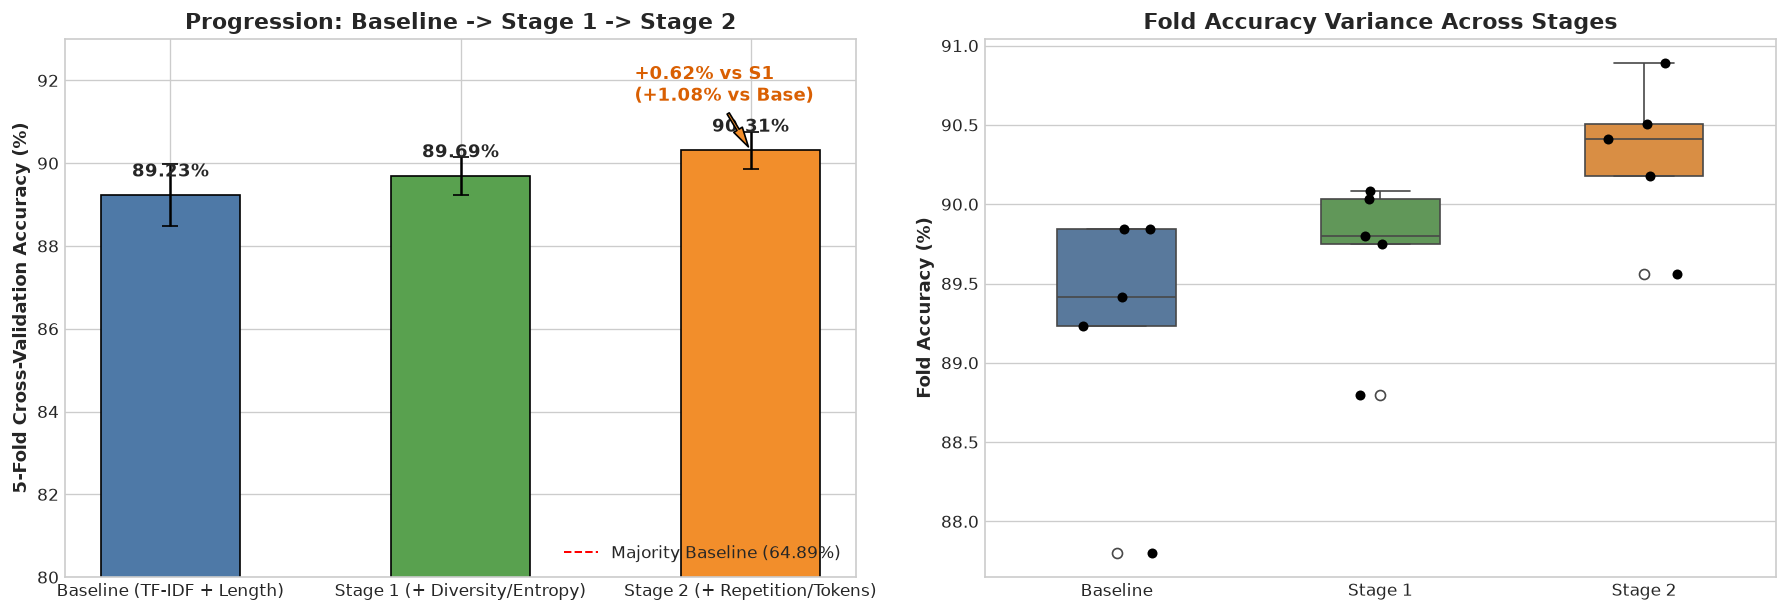

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

# 1. Bar Chart Comparison
ax1 = axes[0]
stages = ["Baseline (TF-IDF + Length)", "Stage 1 (+ Diversity/Entropy)", "Stage 2 (+ Repetition/Tokens)"]
means = [base_mean, s1_mean, s2_mean]
stds = [base_std, s1_std, s2_std]
colors = ["#4e79a7", "#59a14f", "#f28e2b"]

bars = ax1.bar(stages, means, yerr=stds, capsize=5, color=colors, width=0.48, edgecolor="black")
ax1.axhline(majority_baseline, color="red", linestyle="--", linewidth=1.2, label=f"Majority Baseline ({majority_baseline:.2f}%)")
ax1.set_ylim(80, 93)
ax1.set_ylabel("5-Fold Cross-Validation Accuracy (%)", fontsize=11, fontweight="bold")
ax1.set_title("Progression: Baseline -> Stage 1 -> Stage 2", fontsize=13, fontweight="bold")
ax1.legend(loc="lower right")

for bar, val in zip(bars, means):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.35, f"{val:.2f}%", ha="center", va="bottom", fontweight="bold", fontsize=10.5)

ax1.annotate(f"+0.62% vs S1\n(+1.08% vs Base)", xy=(2, s2_mean), xytext=(1.6, s2_mean + 1.2),
             arrowprops=dict(facecolor="#f28e2b", shrink=0.08, width=1.5, headwidth=6),
             fontweight="bold", color="#d95f02", fontsize=10.5)

# 2. Fold-by-fold Boxplot
ax2 = axes[1]
fold_df = pd.DataFrame({
    "Baseline": base_accs,
    "Stage 1": s1_accs,
    "Stage 2": s2_accs
})
sns.boxplot(data=fold_df, ax=ax2, palette=colors, width=0.45)
sns.stripplot(data=fold_df, ax=ax2, color="black", size=6, jitter=0.15)
ax2.set_ylabel("Fold Accuracy (%)", fontsize=11, fontweight="bold")
ax2.set_title("Fold Accuracy Variance Across Stages", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()


## 5. Artifact Export


In [6]:
os.makedirs("data", exist_ok=True)
out_file = "data/stage_2_evaluation_metrics.json"

export_data = {
    "stage": 2,
    "stage_name": "Stage 2: Local N-Gram Repetition & Token ID Profiling",
    "features_added": s2_feature_names,
    "baseline_mean_acc": base_mean,
    "stage1_mean_acc": s1_mean,
    "stage2_mean_acc": s2_mean,
    "stage2_std_acc": s2_std,
    "delta_vs_baseline": delta_base,
    "delta_vs_previous_stage": delta_prev,
    "fold_accuracies": s2_accs
}

with open(out_file, "w") as f:
    json.dump(export_data, f, indent=2)

print(f"Successfully exported Stage 2 metrics to '{out_file}'!")


Successfully exported Stage 2 metrics to 'data/stage_2_evaluation_metrics.json'!
